**This is the For Checking the Images for training and Testing data using the BarPlot .**

In [7]:
from src import config

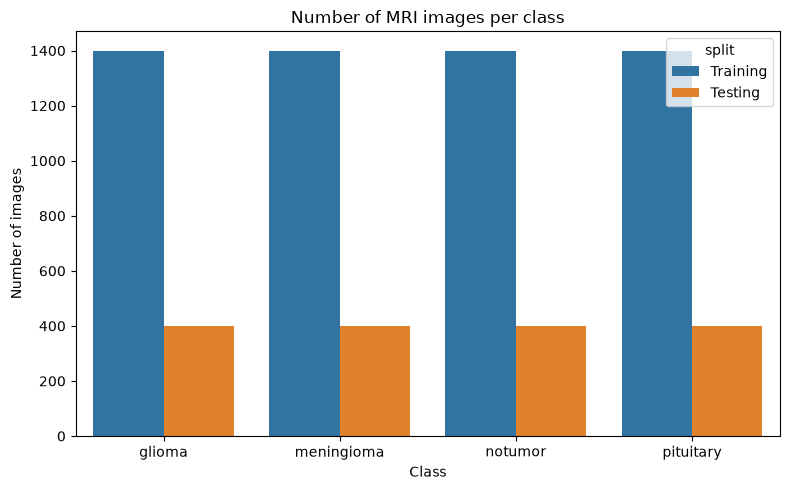

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=counts, x="class", y="images", hue="split")
plt.title("Number of MRI images per class")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "class_distribution.png", dpi=150)
plt.show()

**And this is done because we have imported this from src and check the data / count the images in the number.**

In [9]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # lets the notebook import from src/

import pandas as pd
from src import config

rows = []
for split_name, split_dir in [("Training", config.TRAIN_DIR), ("Testing", config.TEST_DIR)]:
    for class_name in config.CLASS_NAMES:
        class_dir = split_dir / class_name
        count = sum(1 for f in class_dir.iterdir() if f.suffix.lower() in config.IMAGE_EXTENSIONS)
        rows.append({"split": split_name, "class": class_name, "images": count})

counts = pd.DataFrame(rows)
counts.pivot(index="class", columns="split", values="images")

split,Testing,Training
class,,
glioma,400,1400
meningioma,400,1400
notumor,400,1400
pituitary,400,1400


**WE are checking some random Images from the different views , Different Scan types , different size and crops , and Artefacts.** 

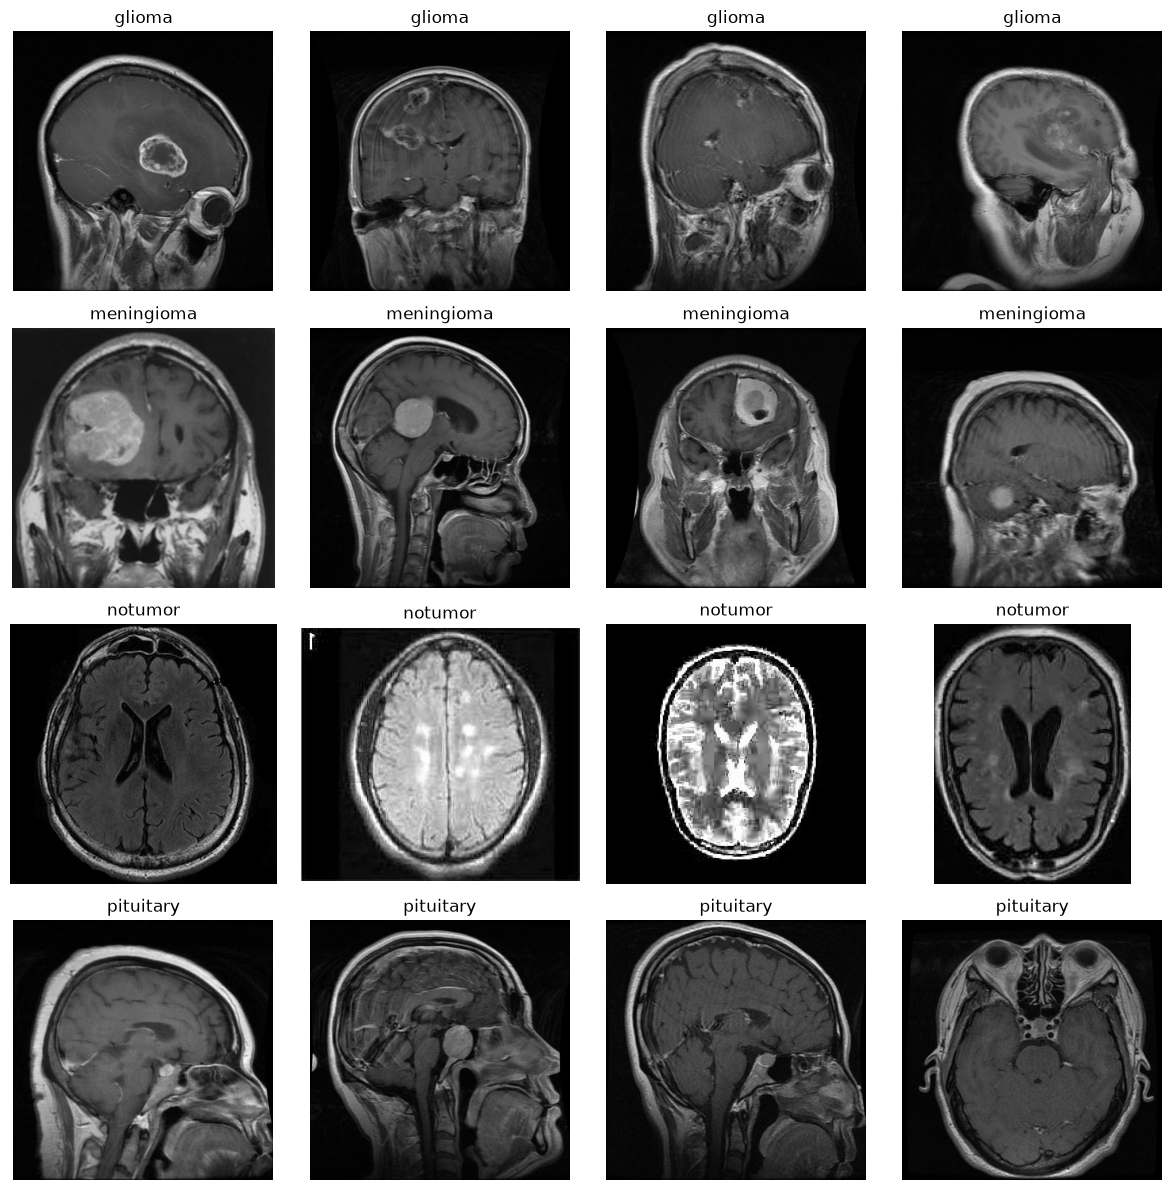

In [4]:
import random
from PIL import Image

random.seed(42)   # same random pictures every time you run it

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for row, class_name in enumerate(config.CLASS_NAMES):
    class_dir = config.TRAIN_DIR / class_name
    files = [f for f in class_dir.iterdir() if f.suffix.lower() in config.IMAGE_EXTENSIONS]
    for col, img_path in enumerate(random.sample(files, 4)):
        img = Image.open(img_path)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "sample_images.png", dpi=150)
plt.show()

**Checking Image sizes, colour modes and unreadable files.**

In [5]:
from collections import Counter

records = []
bad_files = []

for split_name, split_dir in [("Training", config.TRAIN_DIR), ("Testing", config.TEST_DIR)]:
    for class_name in config.CLASS_NAMES:
        for img_path in (split_dir / class_name).iterdir():
            if img_path.suffix.lower() not in config.IMAGE_EXTENSIONS:
                continue
            try:
                with Image.open(img_path) as img:
                    img.verify()                      # checks the file is not corrupted
                with Image.open(img_path) as img:     # reopen, because verify() closes the image
                    records.append({
                        "split": split_name, "class": class_name, "file": img_path.name,
                        "width": img.width, "height": img.height, "mode": img.mode,
                    })
            except Exception as error:
                bad_files.append((img_path, str(error)))

meta = pd.DataFrame(records)
print("Readable images:", len(meta))
print("Unreadable images:", len(bad_files))
print("\nColour modes:")
print(meta["mode"].value_counts())
print("\nMost common sizes (width, height):")
print(meta.groupby(["width", "height"]).size().sort_values(ascending=False).head(10))
print("\nSize range:")
print(meta[["width", "height"]].describe().loc[["min", "max", "mean"]])

Readable images: 7200
Unreadable images: 0

Colour modes:
mode
RGB     4129
L       3067
RGBA       3
P          1
Name: count, dtype: int64

Most common sizes (width, height):
width  height
512    512       5014
225    225        338
630    630         90
201    251         57
228    221         51
232    217         50
236    236         48
442    442         48
150    198         44
200    252         43
dtype: int64

Size range:
            width       height
min    150.000000   167.000000
max   1375.000000  1446.000000
mean   453.302917   456.899167


In [6]:
# Is colour mode related to the class?
print(pd.crosstab(meta["class"], meta["mode"]))

# Is image size related to the class?
meta["is_512"] = (meta["width"] == 512) & (meta["height"] == 512)
print()
print(pd.crosstab(meta["class"], meta["is_512"]))

# Average size per class
print()
print(meta.groupby("class")[["width", "height"]].mean().round(0))

mode           L  P   RGB  RGBA
class                          
glioma      1399  0   401     0
meningioma   709  0  1091     0
notumor       29  1  1767     3
pituitary    930  0   870     0

is_512      False  True 
class                   
glioma         76   1724
meningioma    250   1550
notumor      1780     20
pituitary      80   1720

            width  height
class                    
glioma      507.0   508.0
meningioma  487.0   489.0
notumor     308.0   319.0
pituitary   512.0   511.0


**Duplicate and leakage check**

In [10]:
import hashlib
import numpy as np

def file_md5(path):
    """Fingerprint of the raw file. Identical files give identical values."""
    return hashlib.md5(path.read_bytes()).hexdigest()

def image_dhash(path, hash_size=8):
    """Difference hash: a small fingerprint of how brightness changes across the image.
    Resized or re-saved copies of the same picture get the same (or almost the same) value."""
    with Image.open(path) as img:
        small = img.convert("L").resize((hash_size + 1, hash_size), Image.LANCZOS)
    pixels = np.asarray(small, dtype=np.int16)
    brighter_than_left = pixels[:, 1:] > pixels[:, :-1]
    bits = "".join("1" if b else "0" for b in brighter_than_left.flatten())
    return format(int(bits, 2), "016x")

meta["path"] = meta.apply(lambda r: config.RAW_DATA_DIR / r["split"] / r["class"] / r["file"], axis=1)
meta["md5"] = meta["path"].apply(file_md5)
meta["dhash"] = meta["path"].apply(image_dhash)

# 1. Duplicates inside the whole dataset
print("Files with an exact byte-identical copy:", meta.duplicated("md5", keep=False).sum())
print("Files with an identical visual fingerprint:", meta.duplicated("dhash", keep=False).sum())

# 2. Leakage: same fingerprint in BOTH Training and Testing
for col in ["md5", "dhash"]:
    train_set = set(meta[meta["split"] == "Training"][col])
    test_rows = meta[meta["split"] == "Testing"]
    leaked = test_rows[test_rows[col].isin(train_set)]
    print(f"Test images whose {col} also appears in Training:", len(leaked))

# 3. Same fingerprint under different class labels (would be a labelling problem)
classes_per_hash = meta.groupby("dhash")["class"].nunique()
print("Fingerprints that appear under more than one class:", (classes_per_hash > 1).sum())

Files with an exact byte-identical copy: 340
Files with an identical visual fingerprint: 1614
Test images whose md5 also appears in Training: 0
Test images whose dhash also appears in Training: 372
Fingerprints that appear under more than one class: 1


**Verify the suspected leakage.**

Exact-duplicate groups: 153
Groups spanning more than one class: 0
Groups spanning both Training and Testing: 0

Test images whose strict dhash16 also appears in Training: 160


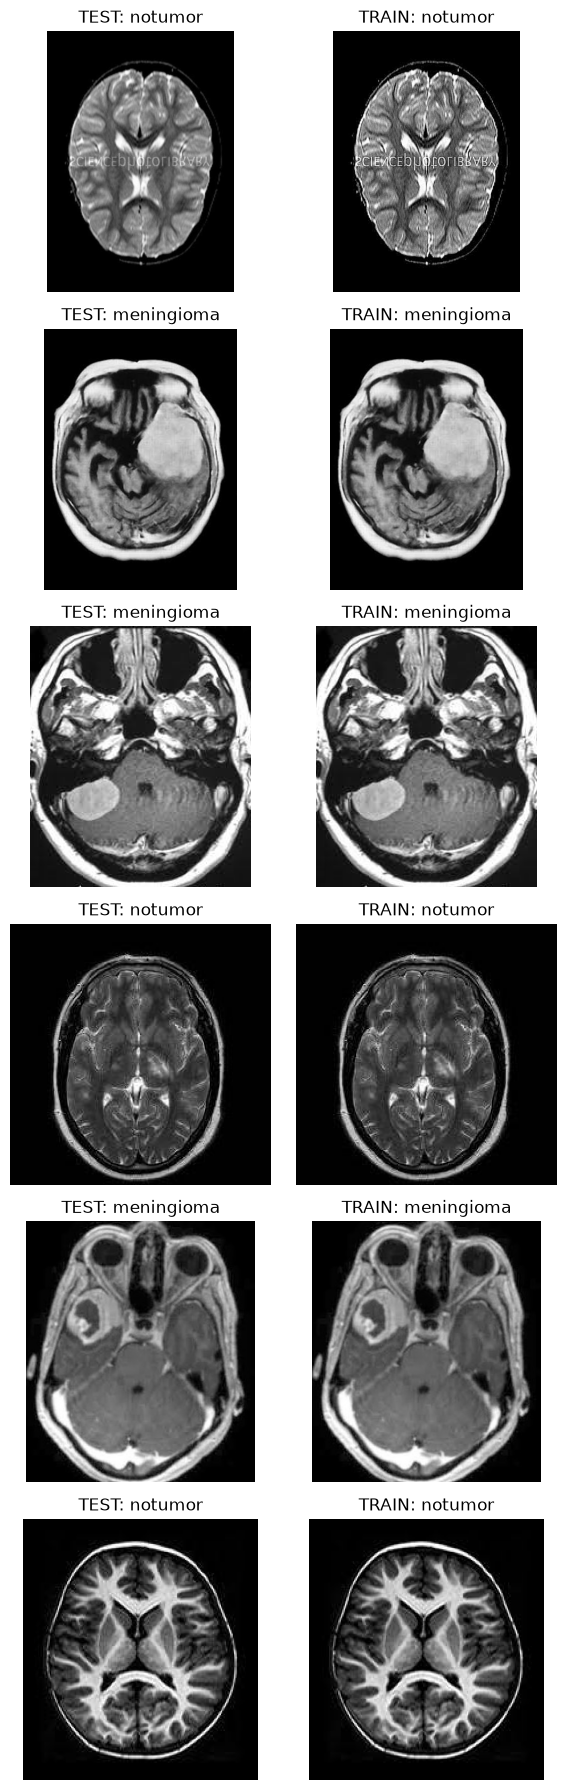

In [11]:
# A. Exact duplicates: where do they sit?
exact = meta[meta.duplicated("md5", keep=False)]
groups = exact.groupby("md5").agg(
    copies=("file", "count"), n_classes=("class", "nunique"), n_splits=("split", "nunique")
)
print("Exact-duplicate groups:", len(groups))
print("Groups spanning more than one class:", (groups["n_classes"] > 1).sum())
print("Groups spanning both Training and Testing:", (groups["n_splits"] > 1).sum())

# B. Stricter fingerprint (256 bits instead of 64)
meta["dhash16"] = meta["path"].apply(lambda p: image_dhash(p, hash_size=16))
train_hashes = set(meta[meta["split"] == "Training"]["dhash16"])
test_rows = meta[meta["split"] == "Testing"]
print("\nTest images whose strict dhash16 also appears in Training:",
      test_rows["dhash16"].isin(train_hashes).sum())

# C. Look at 6 suspected pairs (8x8 hash matches) side by side
train_by_hash = meta[meta["split"] == "Training"].drop_duplicates("dhash").set_index("dhash")
suspects = test_rows[test_rows["dhash"].isin(train_by_hash.index)].sample(6, random_state=42)

fig, axes = plt.subplots(6, 2, figsize=(6, 18))
for i, (_, test_row) in enumerate(suspects.iterrows()):
    train_row = train_by_hash.loc[test_row["dhash"]]
    axes[i, 0].imshow(Image.open(test_row["path"]), cmap="gray")
    axes[i, 0].set_title(f"TEST: {test_row['class']}")
    axes[i, 1].imshow(Image.open(train_row["path"]), cmap="gray")
    axes[i, 1].set_title(f"TRAIN: {train_row['class']}")
    axes[i, 0].axis("off"); axes[i, 1].axis("off")
plt.tight_layout()
plt.show()

In [12]:
for split_name in ["Training", "Testing"]:
    subset = meta[meta["split"] == split_name]
    print(split_name, "- extra duplicate files:", subset.duplicated("md5").sum())

Training - extra duplicate files: 171
Testing - extra duplicate files: 16


In [14]:
train_hashes = set(meta[meta["split"] == "Training"]["dhash16"])
test_rows = meta[meta["split"] == "Testing"]
print("Strict matches Test->Train:", test_rows["dhash16"].isin(train_hashes).sum())

Strict matches Test->Train: 160


**Preparing Dataset manifest**

In [13]:
# Mark exact duplicates: the first copy is kept, later copies are flagged
meta["is_exact_duplicate"] = meta.duplicated("md5", keep="first")

# Relative paths (from the project folder) work on any computer
meta["relative_path"] = meta["path"].apply(
    lambda p: p.relative_to(config.PROJECT_ROOT).as_posix()
)

manifest = meta[["split", "class", "relative_path", "width", "height",
                 "mode", "md5", "dhash", "is_exact_duplicate"]]

processed_dir = config.PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
manifest.to_csv(processed_dir / "dataset_manifest.csv", index=False)

# How many duplicates per split and class?
print(manifest.groupby(["split", "class"])["is_exact_duplicate"].sum().unstack())

# Training images left after removing exact duplicates
train_clean = manifest[(manifest["split"] == "Training") & (~manifest["is_exact_duplicate"])]
print("\nTraining images after removing exact duplicates:", len(train_clean))
print(train_clean["class"].value_counts())

class     glioma  meningioma  notumor  pituitary
split                                           
Testing       14           2        0          0
Training       0          14      119         38

Training images after removing exact duplicates: 5429
class
glioma        1400
meningioma    1386
pituitary     1362
notumor       1281
Name: count, dtype: int64


In [15]:
# Training images whose strict fingerprint also appears in Testing
test_hashes = set(meta[meta["split"] == "Testing"]["dhash16"])
is_train = meta["split"] == "Training"

meta["leaks_into_test"] = is_train & meta["dhash16"].isin(test_hashes)
meta["exclude_from_training"] = is_train & (meta["is_exact_duplicate"] | meta["leaks_into_test"])

print("Training images with a near-twin in Testing:", meta["leaks_into_test"].sum())
print(meta[meta["leaks_into_test"]]["class"].value_counts())

clean_train = meta[is_train & ~meta["exclude_from_training"]]
print("\nTraining images kept:", len(clean_train))
print(clean_train["class"].value_counts())

# Save the updated manifest (nothing is deleted from disk)
manifest = meta[["split", "class", "relative_path", "width", "height", "mode",
                 "md5", "dhash", "dhash16", "is_exact_duplicate",
                 "leaks_into_test", "exclude_from_training"]]
manifest.to_csv(config.PROJECT_ROOT / "data" / "processed" / "dataset_manifest.csv", index=False)

Training images with a near-twin in Testing: 167
class
meningioma    103
notumor        60
glioma          4
Name: count, dtype: int64

Training images kept: 5268
class
glioma        1396
pituitary     1362
meningioma    1287
notumor       1223
Name: count, dtype: int64
